Let's load the necessary libraries

In [1]:
import pandas as pd # Used for data manipulation
import numpy as np # Used for numerical operations
import matplotlib.pyplot as plt # Used for plotting
import seaborn as sns # Used for plotting
from huggingface_hub import login # Used to log in to Hugging Face and access datasets
import spacy # Used for text preprocessing and NLP tasks
from spacytextblob.spacytextblob import SpacyTextBlob # Used for dictionary-based sentiment analysis
from sklearn.feature_extraction.text import TfidfVectorizer # Used for creating TF-IDF representations of the text
from sklearn.model_selection import train_test_split # Used for splitting the dataset into training and testing sets
from sklearn.ensemble import RandomForestClassifier # Used for training a Random Forest classifier
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, recall_score, precision_score # Used for evaluating the performance of the model

We will use a pre-labeled dataset for sentence-level sentiment analysis of ECB speeches [@Pfeifer2023], which is available on Hugging Face ([Central Bank Communication Dataset](https://huggingface.co/datasets/Moritz-Pfeifer/CentralBankCommunication)). The dataset contains sentences from ECB speeches that have been labeled as positive or negative in terms of sentiment.

Let's load the dataset into a pandas DataFrame

In [2]:
df = pd.read_csv("hf://datasets/Moritz-Pfeifer/CentralBankCommunication/Sentiment/ECB_prelabelled_sent.csv")

### Data Exploration

Let's get some basic information about the dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2563 entries, 0 to 2562
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       2563 non-null   object
 1   sentiment  2563 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 40.2+ KB


The dataset contains two columns: "text", which contains the text of the sentence, and "sentiment", which contains the sentiment label (0 for negative, 1 for positive). Let's take a look at the first few rows of the dataset

In [4]:
df.head()

,text,sentiment
0,target2 is seen as a tool to promote the furth...,1
1,the slovak republic for example is now home to...,1
2,the earlier this happens the earlier economic ...,1
3,the bank has made essential contributions in k...,1
4,moreover the economic size and welldeveloped f...,1


Let's check the distribution of the sentiment labels in the dataset. This will give us an idea of whether the dataset is balanced or if there is a class imbalance that we need to be aware of when training our models.

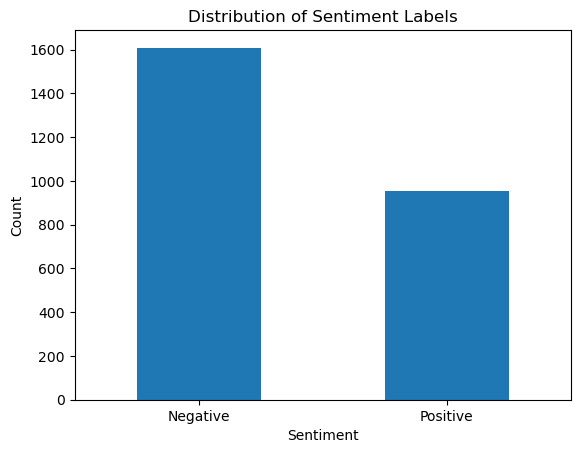

In [5]:
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Distribution of Sentiment Labels")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=["Negative", "Positive"], rotation=0)
plt.show()

There is a slight imbalance but it is not as severe as in some other datasets that we have seen.


### Dictionary-Based Approach to Sentiment Analysis

We can use the SpacyTextBlob component to perform dictionary-based sentiment analysis. This component uses the TextBlob library under the hood, which provides a simple API for performing sentiment analysis based on a predefined lexicon of words and their associated sentiment scores.

In [6]:
# Load the spaCy English model and add the SpacyTextBlob component to the pipeline
nlp = spacy.load('en_core_web_sm')
nlp.add_pipe('spacytextblob')

# Example of how to use the SpacyTextBlob component for sentiment analysis
text = "The ECB's monetary policy is very effective in stabilizing the economy."
doc = nlp(text)
print(f"{text}: {doc._.blob.polarity}")

# Opposite example
text = "The ECB's monetary policy is not suitable for stabilizing the economy."
doc = nlp(text)
print(f"{text}: {doc._.blob.polarity}")

The ECB's monetary policy is very effective in stabilizing the economy.: 0.78
The ECB's monetary policy is not suitable for stabilizing the economy.: -0.275


Note that the polarity score ranges from -1 (very negative) to 1 (very positive), with 0 being neutral. This is different from the binary sentiment labels in our dataset, so we will need to convert the polarity scores to binary labels if we want to compare the results directly.

Also, note that the dictionary-based approach may not always capture the nuances of the language, especially in complex sentences or when there are negations. 

In [7]:
text = "The ECB's monetary policy is not very effective for stabilizing the economy."
doc = nlp(text)
print(f"{text}: {doc._.blob.polarity}")

text = "The ECB's monetary policy is very ineffective for stabilizing the economy."
doc = nlp(text)
print(f"{text}: {doc._.blob.polarity}")

The ECB's monetary policy is not very effective for stabilizing the economy.: -0.23076923076923073
The ECB's monetary policy is very ineffective for stabilizing the economy.: 0.2


The second sentence is more negative than the first one, but the polarity score does not reflect that.

Let's apply the SpacyTextBlob component to the entire dataset and see how well it performs in terms of classifying the sentiment of the sentences

In [8]:
df['textblob_sentiment'] = df['text'].apply(lambda x: nlp(x)._.blob.polarity)

Now we can convert the polarity scores to binary labels using a simple threshold 

In [9]:
df['textblob_label'] = df['textblob_sentiment'].apply(lambda x: 1 if x > 0 else 0)

Now we can evaluate the performance of the dictionary-based approach by comparing the predicted labels with the true labels in the dataset. We can use metrics such as accuracy, precision, and recall to assess the performance of the model

In [10]:
accuracy = accuracy_score(df['sentiment'], df['textblob_label'])
recall = recall_score(df['sentiment'], df['textblob_label'])
precision = precision_score(df['sentiment'], df['textblob_label'])

print(f"Accuracy: {accuracy:.2f}")
print(f"Recall: {recall:.2f}")
print(f"Precision: {precision:.2f}")

Accuracy: 0.59
Recall: 0.78
Precision: 0.47


Note that we did not have to train any model for the dictionary-based approach, as it relies on a predefined lexicon of words and their associated sentiment scores. However, the performance of this approach may not be as good as more advanced machine learning methods, especially if the dataset contains a lot of domain-specific language or if the sentences are complex and contain multiple sentiments.


### Machine Learning Approach to Sentiment Analysis


For the machine learning approach, we will need to preprocess the text data and convert it into a format that can be used as input for a machine learning model. This typically involves steps such as tokenization, stopword removal, and creating numerical representations of the text (e.g., using bag-of-words or TF-IDF).

Let's start by defining a function to preprocess the text data

In [11]:
def preprocess_texts(texts):

    # Use the spaCy pipeline to process the texts, which will handle tokenization, stopword removal, and lemmatization for us
    docs = nlp.pipe(texts, disable=["tok2vec", "parser", "ner"])

    processed_texts = []
    for doc in docs:

        # Lemmatize the tokens and convert them to lowercase, while also removing stopwords, punctuation, whitespace, and numbers
        tokens = [token.lemma_.lower() for token in doc 
            if not token.is_stop and 
            not token.is_punct and 
            not token.is_space and 
            not token.like_num
        ]

        # Join the tokens back into a single string and add it to the list of processed texts
        processed_texts.append(" ".join(tokens))

    return processed_texts

In [12]:
df['processed_text'] = preprocess_texts(df['text'])

First, we need to split the dataset into a training set and a testing set. It's important to do this before vectorization to avoid data leakage.

In [13]:
X = df['processed_text']
y = df['sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # We use 20% of the data for testing, set a random state for reproducibility, and stratify to maintain class balance

Now we can create a TF-IDF representation of the processed text data. Importantly, we fit the vectorizer only on the training data to avoid data leakage, then transform both the training and test sets.

In [14]:
vectorizer = TfidfVectorizer(max_features=1000) # We limit the number of features to 1000 to reduce the dimensionality of the data and speed up the training process
X_train = vectorizer.fit_transform(X_train) # Fit on training data only
X_test = vectorizer.transform(X_test) # Transform test data using the fitted vectorizer

Then, we can train a Random Forest classifier on the training data

In [15]:
clf_rf = RandomForestClassifier(n_estimators=100, random_state = 42).fit(X_train, y_train)

To evaluate the performance of the model, we can make predictions on the testing set and calculate metrics such as accuracy, precision, and recall

In [16]:
y_pred_rf = clf_rf.predict(X_test)
y_proba_rf = clf_rf.predict_proba(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)}")
print(f"Precision: {precision_score(y_test, y_pred_rf)}")
print(f"Recall: {recall_score(y_test, y_pred_rf)}")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba_rf[:, 1])}")

Accuracy: 0.9103313840155945
Precision: 0.9050279329608939
Recall: 0.8481675392670157
ROC AUC: 0.9665132841208415


Our machine learning model does perform quite well on the testing set. We can also visualize the confusion matrix to see how well the model is classifying the positive and negative sentences

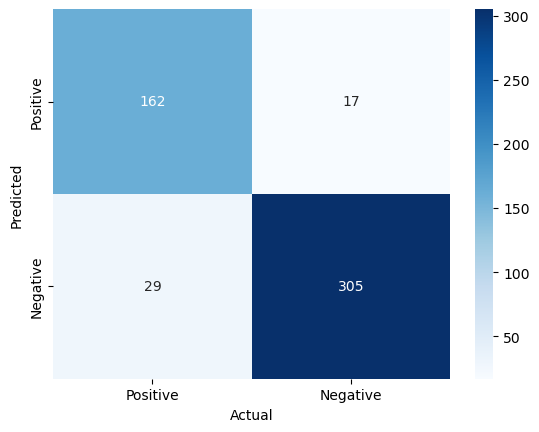

In [17]:
conf_mat = confusion_matrix(y_test, y_pred_rf, labels=[1, 0]).transpose() # Transpose the sklearn confusion matrix to match the convention in the lecture
sns.heatmap(conf_mat, annot=True, cmap='Blues', fmt='g', xticklabels=['Positive', 'Negative'], yticklabels=['Positive', 'Negative'])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

Let's try the sentences that we used for the dictionary-based approach and see how the machine learning model classifies them

In [18]:
test_sentences = pd.Series([
    "The ECB's monetary policy is not very effective for stabilizing the economy.",
    "The ECB's monetary policy is very ineffective for stabilizing the economy."
])
test_processed = preprocess_texts(test_sentences)
test_vectorized = vectorizer.transform(test_processed)
test_pred_rf = clf_rf.predict(test_vectorized)
print(test_sentences[0], "->", "Positive" if test_pred_rf[0] == 1 else "Negative")
print(test_sentences[1], "->", "Positive" if test_pred_rf[1] == 1 else "Negative")

The ECB's monetary policy is not very effective for stabilizing the economy. -> Negative
The ECB's monetary policy is very ineffective for stabilizing the economy. -> Negative


Our machine learning model is able to capture the difference in sentiment between the two sentences, while the dictionary-based approach was not. This is because the machine learning model can learn from the context and the combination of words in the sentences, while the dictionary-based approach relies on predefined sentiment scores for individual words, which may not always capture the nuances of the language.

We could do many more things to improve the performance of our machine learning model, such as hyperparameter tuning, using more advanced models (e.g., gradient boosting, or deep learning models), or using word embeddings instead of TF-IDF representations. However, this should give you a good starting point for performing sentiment analysis using both dictionary-based and machine learning approaches.